# sKF-L from the joint posterior (new Section 3) against the marginal and minorized filters, with the Gaussian sKF as baseline

The scenario of notebook 03: an $M = 128$ room impulse response, correlated input and heavy-tailed noise
($\beta^* = 0.2$) at SNR $= 5$ dB. Metric: misalignment
$10\log_{10}\left(\|w_t - h_o\|^2/\|h_o\|^2\right)$, averaged over realisations.

## 1. Imports

In [1]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import lfilter
from scipy.special import gammaln, log_ndtr
from scipy.stats import gennorm
import rir_generator as rir

NOTEBOOK_START = time.time()                   # for the total printed at the very end
print("imports ready")

imports ready


## 2. The scenario

* **Room:** $h_o$ = first $M = 128$ samples of the $(5, 10, 6)$ m room of section 7.1, $T_{60} = 200$ ms, 8 kHz. Fixed.
* **Input:** $x_t = -0.9\,x_{t-1} + u_t$, unit variance. **Observation:** $d_t = x_t^{\mathsf T}h_o + \eta_t$.
* **Noise:** generalized Gaussian, $\beta^* = 0.2$, at SNR $= 5$ dB, as in Fig. 3 of the paper.
* **What the filters assume:** Laplacian noise of scale $b_\eta = \mathrm{E}|\eta_t|$; the Gaussian baseline, variance $v_\eta = \mathrm{Var}[\eta_t]$.
* the Laplacian closest to the true noise in KL, as in eq. (10); notebooks 03-06 used $\sqrt{v_\eta/2}$.
* **Run:** $N = 96000$ steps, 12 s at 8 kHz, and $R = 20$ realisations.

In [2]:
M = 128                     # filter length / length of the impulse response
N = 96000                   # steps per run (12 s at 8 kHz, the span of Fig. 3a of the paper)
R = 20                      # independent realisations
WARMUP = 500                # AR samples discarded so the input starts stationary

# AR_A = 0.0 reproduces the white input of notebook 05; BETA = 1.0, with TARGET_DB = -15 in
# section 4, reproduces the Laplacian noise of notebook 06. The cache of section 4 keys on the
# b_eta convention alone, so change B_ETA_RULE or CACHE_PREFIX there as well when you change
# AR_A or BETA, or the sweep will load the results of another scenario.
AR_A = -0.9                 # AR(1) coefficient of the input
SNR_DB = 5.0                # nominal signal-to-noise ratio, as in Fig. 3 of the paper
BETA = 0.2                  # shape of the generalized Gaussian measurement noise
VAR_THETA_0 = 2.0           # initial prior variance on each weight, as in notebooks 01 and 02
FS = 8000                   # sampling rate [Hz], the rate of section 7.1 of the draft

# The room of section 7.1 of the draft, simulated with ref. [24] (image method).
ROOM = [5, 10, 6]           # room dimensions [m]
T60 = 0.2                   # reverberation time [s]
C_SOUND = 340               # speed of sound [m/s]
SRC = [1, 2.5, 2]           # source position [m]
MIC = [1, 1.5, 1]           # receiver position [m]

# Generated once and then fixed. Normalised to unit norm: misalignment is scale-invariant
# and SNR_DB is imposed below from P_signal, so the normalisation changes nothing except
# keeping the grid of section 4 on the scale notebook 03 tuned it at.
ho = rir.generate(c=C_SOUND, fs=FS, r=MIC, s=SRC, L=ROOM,
                  reverberation_time=T60, nsample=M).flatten()
ho = ho/np.linalg.norm(ho)

# Signal power, in closed form: r[k] = AR_A^|k| for a unit-variance AR(1) input.
lags = np.abs(np.subtract.outer(np.arange(M), np.arange(M)))
Rxx = AR_A**lags
P_signal = ho @ Rxx @ ho

var_eta = P_signal/10**(SNR_DB/10)                 # noise variance that gives SNR_DB

# Scale of the generalized Gaussian with variance var_eta:
# Var = scale^2 Gamma(3/beta)/Gamma(1/beta).
scale_gg = np.sqrt(var_eta/np.exp(gammaln(3/BETA) - gammaln(1/BETA)))


def laplace_scale(var_eta):
    """b_eta = E|eta_t| of the generalized Gaussian of variance var_eta: the Laplacian closest to it
    in KL(p || q), the direction of eq. (10), and its maximum-likelihood fit."""
    scale = np.sqrt(var_eta/np.exp(gammaln(3/BETA) - gammaln(1/BETA)))   # generalized Gaussian scale
    return scale*np.exp(gammaln(2/BETA) - gammaln(1/BETA))               # E|eta| = scale Gamma(2/b)/Gamma(1/b)


b_eta = laplace_scale(var_eta)                     # the scale the filters are told
b_eta_variance = np.sqrt(var_eta/2)                # the scale notebooks 03-06 told them

print(f"signal power = {P_signal:.4f}")
print(f"var_eta      = {var_eta:.4e}   (nominal, at {SNR_DB:.0f} dB SNR)")
print(f"noise scale  = {scale_gg:.4e}   (generalized Gaussian, beta = {BETA})")
print()
print(f"b_eta = E|eta|     = {b_eta:.4e}   (used by the filters)")
print(f"sqrt(var_eta/2)    = {b_eta_variance:.4e}   (old convention, notebooks 03-06): "
      f"{b_eta_variance/b_eta:.2f}x larger")

# At beta = 1 the noise is already a Laplace, and matching E|eta| and matching the variance
# give the same scale. Anywhere else the two conventions part ways.
if BETA == 1.0:
    assert np.isclose(b_eta, b_eta_variance), f"{b_eta} is not {b_eta_variance} at beta = 1"

signal power = 0.8173
var_eta      = 2.5844e-01   (nominal, at 5 dB SNR)
noise scale  = 8.4350e-06   (generalized Gaussian, beta = 0.2)

b_eta = E|eta|     = 1.2754e-01   (used by the filters)
sqrt(var_eta/2)    = 3.5947e-01   (old convention, notebooks 03-06): 2.82x larger


`generate_signals(seed)` returns one realisation: the input `x`, the observation `d` and the noise `eta`.

In [3]:
def generate_signals(seed):
    """One realisation: AR(1) input, its clean output through ho, and heavy-tailed noise."""
    rng = np.random.default_rng(seed)
    u = np.sqrt(1 - AR_A**2)*rng.standard_normal(N + WARMUP)   # driving noise, unit-variance x
    x = lfilter([1.0], [1.0, -AR_A], u)[WARMUP:]               # x_t = AR_A x_{t-1} + u_t
    y = np.convolve(ho, x)[:N]                                 # clean output, y_t = x_t' ho
    eta = gennorm.rvs(BETA, scale=scale_gg, size=N, random_state=rng)
    return x, y + eta, eta


x, d, eta = generate_signals(0)
print("x:", x.shape, " d:", d.shape)
print(f"noise, first realisation: std {eta.std():.4f}, "
      f"median |eta| {np.median(np.abs(eta)):.5f}, max |eta| {np.abs(eta).max():.4f}")

# Control on b_eta: the sampled mean |eta| of this realisation against the closed form above.
print(f"mean |eta|, sampled     : {np.abs(eta).mean():.4e}   "
      f"against b_eta = {b_eta:.4e}, the closed form")

x: (96000,)  d: (96000,)
noise, first realisation: std 0.4831, median |eta| 0.01889, max |eta| 24.7659
mean |eta|, sampled     : 1.2807e-01   against b_eta = 1.2754e-01, the closed form


## 3. The four closed forms

The Gaussian baseline of notebooks 05-06, the minorized filter of Ramiro, the exact one of notebooks 03-06, and the exact one of the new Section 3.
Notation: $e_t = d_t - x_t^{\mathsf T}w_{t-1}$, $\tilde v_t$ predicted variance, $\varepsilon$ process noise, $M$ weights.

### sKF (Gaussian), eqs. (35), (36) and (38) of the new draft

$$\sigma_t^2 = \tilde v_t\|x_t\|^2 \qquad \chi_t = \frac{\sigma_t^2}{\sigma_t^2 + v_\eta}\,e_t \qquad \chi_t' = \frac{\sigma_t^2}{\sigma_t^2 + v_\eta}$$

$$w_t = w_{t-1} + \frac{x_t}{\|x_t\|^2}\,\chi_t \qquad v_t = \tilde v_t\left(1 - \frac{\chi_t'}{M}\right)$$

with $v_\eta = \mathrm{Var}[\eta_t]$, the Gaussian closest to the true noise in KL. The code is the one of notebook 06.

In [4]:
def shift(new_x_sample, x_window):
    L = len(x_window)
    new_x_window = np.zeros(L)
    new_x_window[0] = new_x_sample
    new_x_window[1:] = x_window[:-1]
    return new_x_window


# Copied from notebook 06 (commit db4b3a9), same lines: only the comments now cite the new draft,
# and sigma_t is recorded for the k_t of the tables.
def sKF_gaussian(n, x, d, w0, parameters):
    """Eqs. (35), (36) and (38) of the new draft: Gaussian noise, chi_t linear in e_t."""
    epsilon = parameters["epsilon"]                    # eps, process noise variance
    var_eta = parameters["var_eta"]                    # v_eta, observation noise variance
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    v = parameters["var_theta_0"]                      # v, scalar prior variance on each weight
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step
    sigma_hist = np.zeros((n,))                        # sigma_t at every step, only for k_t

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update, as Augusto does

        if k >= M:                                     # Augusto waits for a full window; same here
            v_tilde = v + epsilon                      # v_tilde = v + eps, eq. (36)
            power = x_t @ x_t                          # ||x_t||^2
            gain = v_tilde/(var_eta + v_tilde*power)   # chi'/||x||^2 = v_tilde/(v_eta + sigma^2), eq. (38)
            w = w + gain*x_t*e[k]                      # w = w + x_t chi/||x||^2, eqs. (35) and (38)
            v = v_tilde*(1 - gain*power/M)             # v = v_tilde (1 - chi'/M), eq. (36)
            sigma_hist[k] = np.sqrt(v_tilde*power)     # sigma_t, eq. (16), recorded for k_t only

    return {"w_hist": w_hist, "e": e, "sigma": sigma_hist}


print("sKF (Gaussian) ready")

sKF (Gaussian) ready


### sKF-L (minorized), eqs. (robust.sKF.mean) and (robust.sKF.variance) of the old draft

The Gaussian sKF with $v_\eta \leftarrow b_\eta|e_t|$:

$$w_t = w_{t-1} + \frac{\tilde v_t\,x_t}{b_\eta|e_t| + \tilde v_t\|x_t\|^2}\,e_t
\qquad v_t = \tilde v_t\left(1 - \frac{1}{M}\frac{\tilde v_t\|x_t\|^2}{b_\eta|e_t| + \tilde v_t\|x_t\|^2}\right)$$

The same filter in the notation of the new Section 3.5:

$$\tau_t = \frac{\tilde v_t\|x_t\|^2}{b_\eta} \qquad \chi_t^{\min} = \frac{\tau_t e_t}{\tau_t + |e_t|} \qquad w_t = w_{t-1} + \frac{x_t}{\|x_t\|^2}\chi_t^{\min} \qquad v_t = \tilde v_t\left(1 - \frac{1}{M}\frac{\chi_t^{\min}}{e_t}\right)$$

eq. (45) of the new draft; substituting $\tau_t$ gives exactly the form above.

In [5]:
def sKF_L_minorized(n, x, d, w0, parameters):
    """Eqs. (robust.sKF.mean) and (robust.sKF.variance): the sKF above with v_eta -> b_eta |e_t|."""
    epsilon = parameters["epsilon"]                    # eps, process noise variance
    b_eta = parameters["b_eta"]                        # b_eta, Laplacian observation scale
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    v = parameters["var_theta_0"]                      # v, scalar prior variance on each weight
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step
    sigma_hist = np.zeros((n,))                        # sigma_t at every step, only for k_t

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update, as Augusto does

        if k >= M:                                     # Augusto waits for a full window; same here
            v_tilde = v + epsilon                      # v_tilde = v + eps
            power = x_t @ x_t                          # ||x_t||^2
            denominator = b_eta*abs(e[k]) + v_tilde*power     # b_eta |e_t| + v_tilde ||x_t||^2
            w = w + x_t*(v_tilde*e[k]/denominator)     # w = w + v_tilde x_t e_t / denominator
            v = v_tilde*(1 - v_tilde*power/(M*denominator))   # v = v_tilde (1 - v_tilde ||x||^2/(M den))
            sigma_hist[k] = np.sqrt(v_tilde*power)     # sigma_t, eq. (16), recorded for k_t only

    return {"w_hist": w_hist, "e": e, "sigma": sigma_hist}


print("sKF-L (minorized) ready")

sKF-L (minorized) ready


### sKF-L (exact, marginal), eqs. (exact.sKF.mean) and (exact.sKF.variance) of `main_minorization.tex`

Same prediction. With $\varsigma = \pm 1$, and $\phi$, $\Phi$ the standard normal pdf and cdf:

$$\kappa_\varsigma = \frac{\varsigma e_t - \tilde v_t\|x_t\|^2/b_\eta}{\sqrt{\tilde v_t}\,\|x_t\|}
\qquad \pi_\varsigma = \mathrm{softmax}\!\left(-\varsigma e_t/b_\eta + \log\Phi(\kappa_\varsigma)\right)
\qquad h(\kappa) = \phi(\kappa)/\Phi(\kappa)$$

$$\Lambda = \pi_+ - \pi_- \qquad \Gamma = \pi_+h(\kappa_+) - \pi_-h(\kappa_-) \qquad
P = \pi_+h(\kappa_+) + \pi_-h(\kappa_-) \qquad Q = \pi_+\kappa_+h(\kappa_+) + \pi_-\kappa_-h(\kappa_-)$$

$$w_t = w_{t-1} + \left(\frac{\tilde v_t}{b_\eta}\Lambda - \frac{\sqrt{\tilde v_t}}{\|x_t\|}\Gamma\right)x_t$$

$$D_t = \gamma^2(1-\Lambda^2) - 2\gamma\lambda(P - \Lambda\Gamma) - \lambda^2(Q + \Gamma^2)
\qquad v_t = \tilde v_t + \frac{1}{M}D_t\|x_t\|^2 \qquad \gamma = \frac{\tilde v_t}{b_\eta},\ \lambda = \frac{\sqrt{\tilde v_t}}{\|x_t\|}$$

In [6]:
SIGN = np.array([1.0, -1.0])                           # the two branches, varsigma = +1 and -1


def softmax_two(log_weights):
    """Softmax of the two log weights: subtract the largest, exponentiate, normalise."""
    weights = np.exp(log_weights - log_weights.max())  # largest becomes 1, nothing overflows
    return weights/weights.sum()                       # sums to 1


def sKF_L_marginal(n, x, d, w0, parameters):
    """Eqs. (exact.sKF.mean) and (exact.sKF.variance) of main_minorization.tex: marginal moments."""
    epsilon = parameters["epsilon"]                    # eps, process noise variance
    b_eta = parameters["b_eta"]                        # b_eta, Laplacian observation scale
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    v = parameters["var_theta_0"]                      # v, scalar prior variance on each weight
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step
    sigma_hist = np.zeros((n,))                        # sigma_t at every step, only for k_t

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update, as Augusto does

        if k >= M:                                     # Augusto waits for a full window; same here
            v_tilde = v + epsilon                      # v_tilde = v + eps
            norm_x = np.sqrt(x_t @ x_t)                # ||x_t||
            power = norm_x**2                          # ||x_t||^2

            # The two mixture arguments. Global: no dependence on the weight index m.
            kappa = (SIGN*e[k] - v_tilde*power/b_eta)/(np.sqrt(v_tilde)*norm_x)

            # Mixture weights, in the log domain. Phi(kappa) underflows and e^{2 e / b_eta}
            # overflows, so neither factor may be formed on its own.
            log_Phi = log_ndtr(kappa)                  # log Phi(kappa), accurate in the left tail
            pi = softmax_two(-SIGN*e[k]/b_eta + log_Phi)

            # Inverse Mills ratio h = phi/Phi, also in the log domain.
            log_phi = -0.5*kappa**2 - 0.5*np.log(2*np.pi)
            h = np.exp(log_phi - log_Phi)

            Lambda = np.sum(SIGN*pi)                   # saturating prediction error, in [-1, 1]
            Gamma = np.sum(SIGN*pi*h)
            P = np.sum(pi*h)
            Q = np.sum(pi*kappa*h)

            w = w + (v_tilde*Lambda/b_eta - np.sqrt(v_tilde)*Gamma/norm_x)*x_t

            gamma = v_tilde/b_eta
            lam = np.sqrt(v_tilde)/norm_x
            D = (gamma**2*(1 - Lambda**2)
                 - 2*gamma*lam*(P - Lambda*Gamma)
                 - lam**2*(Q + Gamma**2))
            v = v_tilde + D*power/M                    # v = v_tilde + D ||x_t||^2 / M
            sigma_hist[k] = np.sqrt(v_tilde)*norm_x    # sigma_t, eq. (16), recorded for k_t only

    return {"w_hist": w_hist, "e": e, "sigma": sigma_hist}


print("sKF-L (exact, marginal) ready")

sKF-L (exact, marginal) ready


### sKF-L (exact, joint), new draft, Section 3

$$\sigma_t^2 = \tilde v_t\|x_t\|^2 \qquad u_t = \frac{e_t}{\sigma_t} \qquad k_t = \frac{\sigma_t}{b_\eta} \qquad \tau_t = \frac{\sigma_t^2}{b_\eta}$$

$$R_t^\pm = \mathcal R(k_t \pm u_t), \quad \mathcal R(z) = \frac{\Phi(-z)}{\phi(z)} \qquad \Lambda_t = \frac{R_t^- - R_t^+}{R_t^- + R_t^+}$$

$$\chi_t = \tau_t\Lambda_t \qquad \chi_t' = \frac{2k_t}{R_t^- + R_t^+} - k_t^2\left(1-\Lambda_t^2\right)$$

$$w_t = w_{t-1} + \frac{x_t}{\|x_t\|^2}\,\chi_t \qquad v_t = \tilde v_t\left(1 - \frac{\chi_t'}{M}\right)$$

Equations (16), (39), (41), (43), (35) and (36) of the new draft.

Numerically, $\mathcal R$ only through its logarithm, $\log\mathcal R(z) = \log\Phi(-z) + z^2/2 + \tfrac12\log 2\pi$, and $\Lambda_t = \tanh\big((\log R_t^- - \log R_t^+)/2\big)$.

Same loop as the Gaussian sKF; the noise enters only through $\chi_t$ and $\chi_t'$.

In [7]:
def log_mills(z):
    """log R(z), with R(z) = Phi(-z)/phi(z) the Mills ratio, eq. (40). R grows like e^{z^2/2} for
    negative z and overflows, so it is only ever handled through its logarithm."""
    return log_ndtr(-z) + 0.5*z**2 + 0.5*np.log(2*np.pi)


def chi_laplacian(e, sigma, b_eta):
    """Correction chi_t(e_t) and its slope chi'_t(e_t) for Laplacian noise, eqs. (39), (41) and (43)."""
    u = e/sigma                                        # u_t = e_t / sigma_t
    k_t = sigma/b_eta                                  # k_t = sigma_t / b_eta
    tau = sigma**2/b_eta                               # tau_t = sigma_t^2 / b_eta, the largest correction
    log_R_minus = log_mills(k_t - u)                   # log R(k_t - u_t)
    log_R_plus = log_mills(k_t + u)                    # log R(k_t + u_t)
    Lambda = np.tanh((log_R_minus - log_R_plus)/2)     # (R- - R+)/(R- + R+), in (-1, 1)
    chi = tau*Lambda                                   # chi = tau Lambda
    chi_slope = (2*k_t*np.exp(-np.logaddexp(log_R_minus, log_R_plus))   # 2k / (R- + R+)
                 - k_t**2*(1 - Lambda**2))                               # - k^2 (1 - Lambda^2)
    return chi, chi_slope


def sKF_L_joint(n, x, d, w0, parameters):
    """Eqs. (35) and (36) of the new draft with the Laplacian chi of eq. (43): joint posterior mean."""
    epsilon = parameters["epsilon"]                    # eps, process noise variance
    b_eta = parameters["b_eta"]                        # b_eta, Laplacian observation scale
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    v = parameters["var_theta_0"]                      # v, scalar prior variance on each weight
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step
    sigma_hist = np.zeros((n,))                        # sigma_t at every step, only for k_t

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update, as Augusto does

        if k >= M:                                     # Augusto waits for a full window; same here
            v_tilde = v + epsilon                      # v_tilde = v + eps
            power = x_t @ x_t                          # ||x_t||^2
            sigma = np.sqrt(v_tilde*power)             # sigma_t = sqrt(v_tilde ||x_t||^2), eq. (16)
            chi, chi_slope = chi_laplacian(e[k], sigma, b_eta)
            w = w + x_t*chi/power                      # w = w + x_t chi / ||x_t||^2, eq. (35)
            v = v_tilde*(1 - chi_slope/M)              # v = v_tilde (1 - chi'/M), eq. (36)
            sigma_hist[k] = sigma                      # recorded for k_t only

    return {"w_hist": w_hist, "e": e, "sigma": sigma_hist}


print("sKF-L (exact, joint) ready")

sKF-L (exact, joint) ready


Three checks: the two exact filters against each other, the slope at the origin against eq. (46), and the cost per step.

In [8]:
EPS_CHECK = 3.45e-6                                # the epsilon notebook 03 picked for the exact filter
w0 = np.zeros(M)                                   # every filter starts from zero
energy_ho = ho @ ho                                # ||ho||^2, the denominator of misalignment
parameters_check = {"epsilon": EPS_CHECK, "b_eta": b_eta, "var_theta_0": VAR_THETA_0}

x, d, eta = generate_signals(0)
microseconds = {}                                  # us/step of each filter, for the third check
weights = {}                                       # w_hist of each filter, for the first
for name, filter_function in [("sKF-L (minorized)", sKF_L_minorized),
                              ("sKF-L (marginal)", sKF_L_marginal),
                              ("sKF-L (joint)", sKF_L_joint)]:
    start = time.perf_counter()
    weights[name] = filter_function(N, x, d, w0, parameters_check)["w_hist"]
    microseconds[name] = (time.perf_counter() - start)/N*1e6

# 1. Joint against marginal: same realisation, same epsilon, the whole run.
w_marginal = weights["sKF-L (marginal)"]
w_joint = weights["sKF-L (joint)"]
db_marginal = 10*np.log10(((w_marginal - ho)**2).sum(axis=1)/energy_ho)
db_joint = 10*np.log10(((w_joint - ho)**2).sum(axis=1)/energy_ho)
print(f"joint against marginal, realisation 0, eps = {EPS_CHECK:.2e}, {N} steps")
print(f"   max |w_joint - w_marginal| : {np.abs(w_joint - w_marginal).max():.2e}   "
      f"(max |w| = {np.abs(w_marginal).max():.2e})")
print(f"   max misalignment gap       : {np.abs(db_joint - db_marginal).max():.2e} dB")
print("   with a Gaussian prior the joint and the marginal posterior share the mean of every")
print("   coefficient, and the sKF averages the same diagonal: the two are the same filter.")

# 2. Slope at the origin, eq. (46). The draft quotes 0.054 at k = 0.07 and 0.525 at k = 1.
print()
print("slope at the origin, chi'(0) of eq. (46)")
for k_t, quoted in [(0.07, 0.054), (1.0, 0.525)]:
    slope = chi_laplacian(0.0, k_t*b_eta, b_eta)[1]
    print(f"   k = {k_t:<5}: {slope:.5f}   (the draft says {quoted})")

# 3. Cost per step, from those same three runs.
print()
print(f"cost per step, one realisation of {N} steps")
for name in ["sKF-L (minorized)", "sKF-L (marginal)", "sKF-L (joint)"]:
    print(f"   {name:<20}{microseconds[name]:>7.1f} us/step")
print(f"   two evaluations of the Mills ratio instead of kappa, pi, h, Lambda, Gamma, P and Q: "
      f"{microseconds['sKF-L (marginal)']/microseconds['sKF-L (joint)']:.1f}x faster")

joint against marginal, realisation 0, eps = 3.45e-06, 96000 steps
   max |w_joint - w_marginal| : 5.71e-11   (max |w| = 8.74e-01)
   max misalignment gap       : 1.77e-09 dB
   with a Gaussian prior the joint and the marginal posterior share the mean of every
   coefficient, and the sKF averages the same diagonal: the two are the same filter.

slope at the origin, chi'(0) of eq. (46)
   k = 0.07 : 0.05411   (the draft says 0.054)
   k = 1.0  : 0.52514   (the draft says 0.525)

cost per step, one realisation of 96000 steps
   sKF-L (minorized)       7.3 us/step
   sKF-L (marginal)       33.3 us/step
   sKF-L (joint)          11.7 us/step
   two evaluations of the Mills ratio instead of kappa, pi, h, Lambda, Gamma, P and Q: 2.9x faster


In [9]:
# Convergence criterion of notebooks 03 and 04, unchanged: floor = mean over the last
# quarter of the run, converged = first step within 3 dB of that floor.
def steady_state(misalignment):
    """Floor in dB, and the first step within 3 dB of it."""
    tail = slice(3*len(misalignment)//4, len(misalignment))
    floor = 10*np.log10(misalignment[tail].mean())
    db = 10*np.log10(misalignment)
    reached = int(np.argmax(db < floor + 3))
    return floor, reached


print("convergence criterion ready")

convergence criterion ready


## 4. Sweeping $\varepsilon$

Each value is one point of a curve of floor against time to converge. **The curve is the filter; the parameter says where on it you stand.**

* **Grid:** two points per decade, the same for the three sKF-L, so the runs are paired point by point. The Gaussian sKF has its own, three decades lower: it converges about ten times more slowly.
* **Settled:** $0 <$ steps $\le N/2$ and the third quarter within $0.5$ dB of the floor. A run still descending reads a floor it never reached; those points are dropped and counted.
* **Selected value:** interpolated over the settled points to land on the target, then run once; if out of reach, the deepest settled point.
* $R = 20$, $N = 96000$, same signals for every filter and every value of $\varepsilon$.

In [10]:
TARGET_DB = -20.0           # target floor, the one notebook 03 uses for this scenario
DRIFT_DB = 0.5              # a settled run's third quarter sits at most this far above its floor

# sweep_filter only compares the grid, R and N, so the b_eta convention goes in the file name:
# results computed with the old sqrt(v_eta/2) live in their own files and are never loaded here.
B_ETA_RULE = "mad"
CACHE_PREFIX = f"../cache/07_joint_{B_ETA_RULE}_"

# One grid for the three filters: the same epsilon on the same signals, point by point.
EPS_GRID = np.logspace(-8, -3, 11)
SWEPT_NAME = "epsilon"

# The Gaussian baseline reaches -20 dB only at a much smaller epsilon (3.16e-8 in notebook 03).
EPS_GRID_GAUSS = np.logspace(-11, -6, 11)

# What each filter is told, besides the epsilon being swept.
PARAMETERS_SKF_L = {"b_eta": b_eta, "var_theta_0": VAR_THETA_0}
PARAMETERS_SKF_GAUSS = {"var_eta": var_eta, "var_theta_0": VAR_THETA_0}   # v_eta = Var[eta]

print(f"the three sKF-L: {len(EPS_GRID)} values of {SWEPT_NAME} over "
      f"{np.log10(EPS_GRID[-1]/EPS_GRID[0]):.0f} decades")
print("   " + "  ".join(f"{value:.1e}" for value in EPS_GRID))
print(f"the Gaussian sKF: {len(EPS_GRID_GAUSS)} values over "
      f"{np.log10(EPS_GRID_GAUSS[-1]/EPS_GRID_GAUSS[0]):.0f} decades")
print("   " + "  ".join(f"{value:.1e}" for value in EPS_GRID_GAUSS))
print(f"\ntarget floor: {TARGET_DB:.1f} dB, the target of notebook 03 at beta* = {BETA}.")

# One set of signals shared by every filter and every epsilon, so the comparison is paired.
sweep_signals = []
for seed in range(R):
    x, d, eta = generate_signals(seed)
    sweep_signals.append((x, d))
print(f"{R} realisations of {N} steps, generated once and shared by the four filters")

the three sKF-L: 11 values of epsilon over 5 decades
   1.0e-08  3.2e-08  1.0e-07  3.2e-07  1.0e-06  3.2e-06  1.0e-05  3.2e-05  1.0e-04  3.2e-04  1.0e-03
the Gaussian sKF: 11 values over 5 decades
   1.0e-11  3.2e-11  1.0e-10  3.2e-10  1.0e-09  3.2e-09  1.0e-08  3.2e-08  1.0e-07  3.2e-07  1.0e-06

target floor: -20.0 dB, the target of notebook 03 at beta* = 0.2.


20 realisations of 96000 steps, generated once and shared by the four filters


The benchmark runs first: one realisation per filter, and the projected cost of the whole sweep.

In [11]:
EPS_BENCHMARK = 3.2e-6                             # near the optimum of the three sKF-L, from notebook 03
EPS_BENCHMARK_GAUSS = 3.2e-8                       # near the optimum of the Gaussian sKF, from notebook 03

x, d, eta = generate_signals(0)

parameters_gauss = PARAMETERS_SKF_GAUSS.copy()
parameters_gauss[SWEPT_NAME] = EPS_BENCHMARK_GAUSS
parameters_laplacian = PARAMETERS_SKF_L.copy()
parameters_laplacian[SWEPT_NAME] = EPS_BENCHMARK

benchmark = [("sKF (Gaussian)", sKF_gaussian, parameters_gauss, EPS_GRID_GAUSS),
             ("sKF-L (minorized)", sKF_L_minorized, parameters_laplacian, EPS_GRID),
             ("sKF-L (marginal)", sKF_L_marginal, parameters_laplacian, EPS_GRID),
             ("sKF-L (joint)", sKF_L_joint, parameters_laplacian, EPS_GRID)]

print(f"one realisation of N = {N} steps per filter\n")
print(f"{'filter':<20}{'us/step':>10}{'s/realisation':>15}{'grid':>6}{'sweep [min]':>13}")
projected = 0.0
for name, filter_function, parameters, grid in benchmark:
    start = time.perf_counter()
    filter_function(N, x, d, w0, parameters)
    seconds = time.perf_counter() - start
    minutes = seconds*R*len(grid)/60                   # its whole grid, at R realisations
    projected += minutes
    print(f"{name:<20}{seconds/N*1e6:>10.1f}{seconds:>15.1f}{len(grid):>6}{minutes:>13.0f}")

print(f"\nprojected sweep, the four filters: {projected:.0f} min")
print("   the selected run of each filter adds one more point per filter")

one realisation of N = 96000 steps per filter

filter                 us/step  s/realisation  grid  sweep [min]


sKF (Gaussian)             8.0            0.8    11            3


sKF-L (minorized)          7.4            0.7    11            3


sKF-L (marginal)          32.8            3.1    11           12


sKF-L (joint)             11.8            1.1    11            4

projected sweep, the four filters: 21 min
   the selected run of each filter adds one more point per filter


In [12]:
def run_filter(filter_function, parameters, n, signals):
    """Average misalignment curve of one filter at one parameter value, over the given signals."""
    misalignment = np.zeros(n)
    for x, d in signals:
        w_hist = filter_function(n, x[:n], d[:n], w0, parameters)["w_hist"]
        misalignment += ((w_hist - ho)**2).sum(axis=1)/energy_ho
    return misalignment/len(signals)


def is_settled(misalignment, drift):
    """Settled within the run: within 3 dB of the floor by half of it, and no longer descending."""
    n = len(misalignment)
    floor, reached = steady_state(misalignment)
    third_quarter = 10*np.log10(misalignment[n//2:3*n//4].mean())
    # reached = 0: the run never left the 3 dB band around its start, so it never converged either
    return bool(0 < reached <= n/2 and third_quarter - floor <= drift)


def pick_parameter(filter_function, swept_name, grid, floors, settled, fixed_parameters):
    """Interpolate, over the settled points, the value that lands on TARGET_DB; run it once."""
    if not settled.any():
        return {"value": np.nan, "floor": np.nan, "reached": -1,
                "status": "nothing settled", "misalignment": np.full(N, np.nan)}

    settled_values, settled_floors = grid[settled], floors[settled]

    if TARGET_DB > settled_floors.max():
        return {"value": np.nan, "floor": settled_floors.max(), "reached": -1,
                "status": "grid too narrow", "misalignment": np.full(N, np.nan)}

    if TARGET_DB < settled_floors.min():
        value = settled_values[np.argmin(settled_floors)]   # its deepest floor instead
        status = "target not reached"
    else:
        order = np.argsort(settled_floors)
        value = 10**np.interp(TARGET_DB, settled_floors[order], np.log10(settled_values)[order])
        status = "ok"

    parameters = fixed_parameters.copy()
    parameters[swept_name] = value
    misalignment = run_filter(filter_function, parameters, N, sweep_signals)
    floor, reached = steady_state(misalignment)
    return {"value": value, "floor": floor, "reached": reached,
            "status": status, "misalignment": misalignment}


def sweep_filter(name, filter_function, swept_name, grid, fixed_parameters, cache_file, drift):
    """Whole grid plus the selected run, for one filter. Cached in its own file."""
    if os.path.exists(cache_file):
        with np.load(cache_file) as stored:
            if (np.array_equal(stored["grid"], grid)
                    and int(stored["R"]) == R and int(stored["N"]) == N):
                print(f"{name:<20} loaded from {cache_file}")
                return {key: stored[key] for key in stored.files}
        print(f"{name:<20} {cache_file} was computed on another grid, R or N: computing again")

    print(f"{name:<20} computing {len(grid)} grid points at R = {R}, N = {N}")
    start = time.time()
    floors = np.zeros(len(grid))
    steps = np.zeros(len(grid), dtype=int)
    settled = np.zeros(len(grid), dtype=bool)

    for i in range(len(grid)):
        parameters = fixed_parameters.copy()
        parameters[swept_name] = grid[i]               # the one parameter this filter sweeps
        misalignment = run_filter(filter_function, parameters, N, sweep_signals)
        floors[i], steps[i] = steady_state(misalignment)
        settled[i] = is_settled(misalignment, drift)
        print(f"   {swept_name} = {grid[i]:.2e}: floor {floors[i]:+7.2f} dB, {steps[i]:>6} steps, "
              f"{'settled' if settled[i] else 'NOT settled'}   [{time.time() - start:.0f} s]")

    selected = pick_parameter(filter_function, swept_name, grid, floors, settled, fixed_parameters)
    result = {"grid": grid, "floors": floors, "steps": steps, "settled": settled,
              "value": selected["value"], "floor": selected["floor"],
              "reached": selected["reached"], "status": selected["status"],
              "misalignment": selected["misalignment"], "R": R, "N": N}
    np.savez(cache_file, **result)
    print(f"{name:<20} done in {(time.time() - start)/60:.1f} min, saved to {cache_file}")
    return result


print("sweep functions ready")

sweep functions ready


Each filter caches its own sweep in `cache/07_joint_<filter>.npz`, reused if the grid, $R$ and $N$ match. Delete one file to recompute that filter alone.

In [13]:
resultado_skf_gauss = sweep_filter(
    "sKF (Gaussian)", sKF_gaussian, SWEPT_NAME, EPS_GRID_GAUSS,
    PARAMETERS_SKF_GAUSS, CACHE_PREFIX + "skf_gauss.npz", DRIFT_DB)

resultado_skf_min = sweep_filter(
    "sKF-L (minorized)", sKF_L_minorized, SWEPT_NAME, EPS_GRID,
    PARAMETERS_SKF_L, CACHE_PREFIX + "skf_min.npz", DRIFT_DB)

resultado_skf_marginal = sweep_filter(
    "sKF-L (marginal)", sKF_L_marginal, SWEPT_NAME, EPS_GRID,
    PARAMETERS_SKF_L, CACHE_PREFIX + "skf_marginal.npz", DRIFT_DB)

resultado_skf_joint = sweep_filter(
    "sKF-L (joint)", sKF_L_joint, SWEPT_NAME, EPS_GRID,
    PARAMETERS_SKF_L, CACHE_PREFIX + "skf_joint.npz", DRIFT_DB)

# Name, result and colour. The Gaussian filter gets its own panel in Figure 1 and stays out of
# Figure 2: it converges about ten times more slowly, so on a common axis nothing compares.
RESULTS_GAUSSIAN = [("sKF (Gaussian)", resultado_skf_gauss, "C0")]
RESULTS_ROBUST = [("sKF-L (minorized)", resultado_skf_min, "C1"),
                  ("sKF-L (marginal)", resultado_skf_marginal, "C2"),
                  ("sKF-L (joint)", resultado_skf_joint, "C3")]
RESULTS = RESULTS_GAUSSIAN + RESULTS_ROBUST            # every table below

sKF (Gaussian)       loaded from ../cache/07_joint_mad_skf_gauss.npz
sKF-L (minorized)    loaded from ../cache/07_joint_mad_skf_min.npz
sKF-L (marginal)     loaded from ../cache/07_joint_mad_skf_marginal.npz
sKF-L (joint)        loaded from ../cache/07_joint_mad_skf_joint.npz


Every grid point, then the discarded count. A warning means the deepest settled point sits on a grid edge, where the curve is cut and the grid has to widen.

In [14]:
print(f"{'filter':<20}{'epsilon':>11}{'floor [dB]':>12}{'steps':>8}  point")
for name, result, colour in RESULTS:
    for value, floor, step, ok in zip(result["grid"], result["floors"],
                                      result["steps"], result["settled"]):
        print(f"{name:<20}{value:>11.1e}{floor:>12.2f}{step:>8}  "
              f"{'settled' if ok else 'not settled'}")

print()
for name, result, colour in RESULTS:
    floors, settled = result["floors"], result["settled"]
    print(f"{name:<20} {int(np.sum(~settled))} of {len(floors)} grid points discarded "
          f"as not settled")
    if not settled.any():
        print("   WARNING: no grid point settled")
        continue
    best = np.flatnonzero(settled)[np.argmin(floors[settled])]
    if best in (0, len(floors) - 1):
        print(f"   WARNING: its best point, {SWEPT_NAME} = {result['grid'][best]:.1e}, "
              f"is on the edge of the grid")

# The two exact filters over the whole grid: same epsilon, same signals, point by point.
floor_gap = np.abs(resultado_skf_marginal["floors"] - resultado_skf_joint["floors"]).max()
step_gap = np.abs(resultado_skf_marginal["steps"] - resultado_skf_joint["steps"]).max()
print(f"\nmarginal against joint, over the {len(EPS_GRID)} grid points: floors differ by at most "
      f"{floor_gap:.2e} dB, steps by at most {int(step_gap)}")

filter                  epsilon  floor [dB]   steps  point
sKF (Gaussian)          1.0e-11      -10.41    2761  settled
sKF (Gaussian)          3.2e-11      -10.47    2873  settled
sKF (Gaussian)          1.0e-10      -10.65    3246  settled
sKF (Gaussian)          3.2e-10      -11.10    4593  not settled
sKF (Gaussian)          1.0e-09      -12.09   12888  not settled
sKF (Gaussian)          3.2e-09      -13.98   36562  not settled
sKF (Gaussian)          1.0e-08      -17.04   52161  not settled
sKF (Gaussian)          3.2e-08      -20.17   53188  not settled
sKF (Gaussian)          1.0e-07      -19.70   32148  settled
sKF (Gaussian)          3.2e-07      -17.20   15709  settled
sKF (Gaussian)          1.0e-06      -14.58    6689  settled
sKF-L (minorized)       1.0e-08      -38.89   73359  not settled
sKF-L (minorized)       3.2e-08      -38.25   43297  settled
sKF-L (minorized)       1.0e-07      -33.52   22730  settled
sKF-L (minorized)       3.2e-07      -28.71   12412  settled
sK

## 5. Results

**Figure 1.** Each filter at the value of $\varepsilon$ that lands its floor on the target: (a) the Gaussian sKF, on its own axis because it converges about ten times more slowly, (b) the three sKF-L. Dotted, in each curve's colour: its floor, its floor $+\,3$ dB and the instant it crosses that threshold; all three are read off the axes. The joint filter is dashed and drawn last, over the marginal one it coincides with.

In [15]:
t_axis = np.arange(N)/FS                           # steps to seconds, as in Fig. 3 of the paper


def add_ticks(ax, axis, values, colours, decimals, min_gap):
    """Put `values` on the axis as ticks, dropping the automatic ones that would collide.

    Two of the values closer than min_gap keep both ticks: their labels go to opposite
    sides of the tick, so that neither hides the other and both numbers stay readable.
    """
    if axis == "x":
        low, high = ax.get_xlim()
        automatic = ax.get_xticks()
    else:
        low, high = ax.get_ylim()
        automatic = ax.get_yticks()

    kept = []                                      # automatic ticks far enough from the values
    for tick in automatic:
        if not low <= tick <= high:
            continue
        distances = []
        for value in values:
            distances.append(abs(tick - value))
        if min(distances) >= min_gap:
            kept.append(tick)

    positions = sorted(kept + list(values))
    labels = []
    for position in positions:
        labels.append(f"{position:.{decimals}f}")

    if axis == "x":
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=90, fontsize=8)
        texts = ax.get_xticklabels()
    else:
        ax.set_yticks(positions)
        ax.set_yticklabels(labels, fontsize=8)
        texts = ax.get_yticklabels()

    # Two added values too close to each other: their labels go to opposite sides.
    nudge = {}
    order = np.argsort(values)
    for rank in range(1, len(order)):
        lower, upper = values[order[rank - 1]], values[order[rank]]
        if abs(upper - lower) < min_gap:
            nudge[lower] = "top" if axis == "y" else "right"
            nudge[upper] = "bottom" if axis == "y" else "left"

    # Each added tick takes the colour of the curve it belongs to.
    for position, text in zip(positions, texts):
        for value, colour in zip(values, colours):
            if position == value:
                text.set_color(colour)
                if value in nudge and axis == "y":
                    text.set_verticalalignment(nudge[value])
                elif value in nudge:
                    text.set_horizontalalignment(nudge[value])


def readable_ticks(values, gap, decimals, log=False):
    """Ticks at every value; a label is blanked when it would print on top of the previous one,
    or when it would round to the same text as the label before it."""
    values = np.unique(values)
    positions = np.log10(values) if log else values
    labels, last_position, last_label = [], -np.inf, ""
    for value, position in zip(values, positions):
        label = f"{value:.{decimals}f}"
        if position - last_position >= gap and label != last_label:
            labels.append(label)
            last_position, last_label = position, label
        else:
            labels.append("")
    return values, labels


def add_value(values, colours, value, colour, decimals):
    """One tick per printed number: a value that prints like one already there only takes its
    colour, so the floor and the instant the joint and the marginal filters share are labelled once."""
    for i in range(len(values)):
        if f"{values[i]:.{decimals}f}" == f"{value:.{decimals}f}":
            colours[i] = colour
            return
    values.append(value)
    colours.append(colour)


print("tick helpers ready")

tick helpers ready


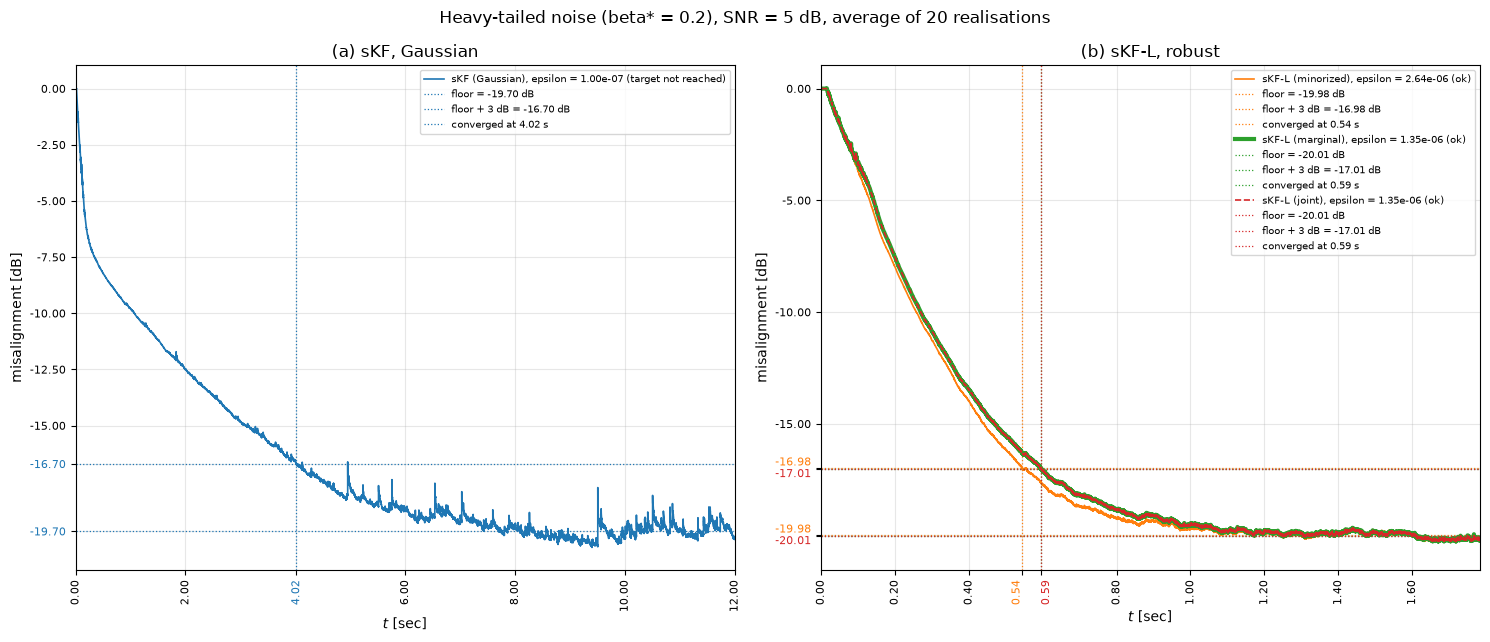

In [16]:
FIGURE1_TITLE = (f"Heavy-tailed noise (beta* = {BETA}), SNR = {SNR_DB:.0f} dB, "
                 f"average of {R} realisations")


def draw_curve(ax, result, name, colour, style, width):
    """One curve, with its floor, its floor + 3 dB and its crossing instant dotted in its colour."""
    floor = float(result["floor"])
    reached = int(result["reached"])
    ax.plot(t_axis, 10*np.log10(result["misalignment"]), color=colour, linestyle=style,
            linewidth=width,
            label=f"{name}, {SWEPT_NAME} = {float(result['value']):.2e} ({result['status']})")
    ax.axhline(floor, color=colour, linestyle=":", linewidth=0.9,
               label=f"floor = {floor:.2f} dB")
    ax.axhline(floor + 3, color=colour, linestyle=":", linewidth=0.9,
               label=f"floor + 3 dB = {floor + 3:.2f} dB")
    ax.axvline(reached/FS, color=colour, linestyle=":", linewidth=0.9,
               label=f"converged at {reached/FS:.2f} s")
    return floor, reached


fig, (ax_gauss, ax_robust) = plt.subplots(1, 2, figsize=(15, 6.5))

for ax, title, curves in [(ax_gauss, "(a) sKF, Gaussian", RESULTS_GAUSSIAN),
                          (ax_robust, "(b) sKF-L, robust", RESULTS_ROBUST)]:
    levels, colours_y, instants, colours_x = [], [], [], []
    slowest = 0
    for name, result, colour in curves:                # joint is last, so it is drawn on top
        # The marginal and the joint curves coincide, so the marginal one is drawn thick and the
        # joint one dashed and thin over it: both are visible everywhere they overlap.
        style = "--" if name == "sKF-L (joint)" else "-"
        width = 3.0 if name == "sKF-L (marginal)" else 1.2
        floor, reached = draw_curve(ax, result, name, colour, style, width)
        add_value(levels, colours_y, floor, colour, 2)
        add_value(levels, colours_y, floor + 3, colour, 2)
        add_value(instants, colours_x, reached/FS, colour, 2)
        slowest = max(slowest, reached)

    ax.set_xlim(0, min(3*slowest, N)/FS)               # three times the slowest convergence
    ax.set_title(title)
    ax.set_xlabel("$t$ [sec]")
    ax.set_ylabel("misalignment [dB]")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="upper right")
    add_ticks(ax, "y", levels, colours_y, 2, 1.5)
    add_ticks(ax, "x", instants, colours_x, 2, 0.08*ax.get_xlim()[1])

fig.suptitle(FIGURE1_TITLE)
plt.tight_layout()
plt.show()

The selected runs. Floor: mean of the last quarter of the run. Converged: first step within 3 dB of that floor.

In [17]:
def k_summary(filter_function, parameters):
    """k_t = sigma_t / E|eta| over one run on realisation 0: median, 10th and 90th percentiles."""
    x, d = sweep_signals[0]
    sigma = filter_function(N, x, d, w0, parameters)["sigma"][M:]   # from the first update on
    k_t = sigma/b_eta                                  # E|eta| for every filter: one axis for all
    return {"median": np.median(k_t), "p10": np.percentile(k_t, 10), "p90": np.percentile(k_t, 90)}


# k_t of each filter at its selected epsilon.
k_runs = {}
for name, filter_function, fixed_parameters, result in [
        ("sKF (Gaussian)", sKF_gaussian, PARAMETERS_SKF_GAUSS, resultado_skf_gauss),
        ("sKF-L (minorized)", sKF_L_minorized, PARAMETERS_SKF_L, resultado_skf_min),
        ("sKF-L (marginal)", sKF_L_marginal, PARAMETERS_SKF_L, resultado_skf_marginal),
        ("sKF-L (joint)", sKF_L_joint, PARAMETERS_SKF_L, resultado_skf_joint)]:
    parameters = fixed_parameters.copy()
    parameters[SWEPT_NAME] = float(result["value"])
    if np.isnan(parameters[SWEPT_NAME]):
        k_runs[name] = {"median": np.nan, "p10": np.nan, "p90": np.nan}
    else:
        k_runs[name] = k_summary(filter_function, parameters)

print(f"{'filter':<20}{'epsilon':>11}{'floor [dB]':>12}{'steps':>9}{'time [s]':>10}"
      f"{'k_t median':>12}{'k_t 10-90%':>16}  status")
for name, result, colour in RESULTS:
    value = float(result["value"])
    reached = int(result["reached"])
    value_text = "-" if np.isnan(value) else f"{value:.2e}"
    steps_text = "-" if reached < 0 else str(reached)
    time_text = "-" if reached < 0 else f"{reached/FS:.2f}"
    k_range = f"{k_runs[name]['p10']:.3f}-{k_runs[name]['p90']:.3f}"
    print(f"{name:<20}{value_text:>11}{float(result['floor']):>12.2f}{steps_text:>9}"
          f"{time_text:>10}{k_runs[name]['median']:>12.3f}{k_range:>16}  {result['status']}")
print("   k_t = sigma_t / E|eta| for every filter, over realisation 0 at the selected epsilon")

print()
steps_min = int(resultado_skf_min["reached"])
floor_min = float(resultado_skf_min["floor"])
for label, result in [("marginal", resultado_skf_marginal), ("joint", resultado_skf_joint)]:
    steps_exact = int(result["reached"])
    if steps_min <= 0 or steps_exact <= 0:
        print(f"{label:<9}/ minorized steps : one of the two never settled, no ratio")
        continue
    print(f"{label:<9}/ minorized steps : {steps_exact}/{steps_min} = "
          f"{steps_exact/steps_min:.2f}x   (floors "
          f"{float(result['floor']) - floor_min:+.2f} dB apart)")

steps_gauss = int(resultado_skf_gauss["reached"])
steps_joint = int(resultado_skf_joint["reached"])
if steps_gauss <= 0 or steps_joint <= 0:
    print("Gaussian / joint steps    : one of the two never settled, no ratio")
else:
    print(f"Gaussian / joint steps    : {steps_gauss}/{steps_joint} = {steps_gauss/steps_joint:.2f}x   "
          f"(floors {float(resultado_skf_gauss['floor']) - float(resultado_skf_joint['floor']):+.2f} dB apart)")
    if resultado_skf_gauss["status"] != "ok":
        print(f"   the Gaussian filter did not land on the target ({resultado_skf_gauss['status']}): "
              f"no settled run of it goes deeper, so this ratio is at unequal floors")

floors_all = []
for name, result, colour in RESULTS:
    floors_all.append(float(result["floor"]))
print(f"\nspread of the four floors   : {max(floors_all) - min(floors_all):.2f} dB")
print(f"target                      : {TARGET_DB:.1f} dB")

filter                  epsilon  floor [dB]    steps  time [s]  k_t median      k_t 10-90%  status
sKF (Gaussian)         1.00e-07      -19.70    32148      4.02       1.121     0.893-1.440  target not reached
sKF-L (minorized)      2.64e-06      -19.98     4357      0.54       1.782     1.428-2.279  ok
sKF-L (marginal)       1.35e-06      -20.01     4756      0.59       1.484     1.197-1.884  ok
sKF-L (joint)          1.35e-06      -20.01     4756      0.59       1.484     1.197-1.884  ok
   k_t = sigma_t / E|eta| for every filter, over realisation 0 at the selected epsilon

marginal / minorized steps : 4756/4357 = 1.09x   (floors -0.02 dB apart)
joint    / minorized steps : 4756/4357 = 1.09x   (floors -0.02 dB apart)
Gaussian / joint steps    : 32148/4756 = 6.76x   (floors +0.30 dB apart)
   the Gaussian filter did not land on the target (target not reached): no settled run of it goes deeper, so this ratio is at unequal floors

spread of the four floors   : 0.30 dB
target            

**Figure 2.** Floor against time to converge, one point per settled value of $\varepsilon$. **Lower and further left is better.** Stars: the runs of Figure 1. A curve below another over the whole common range dominates it: no choice of $\varepsilon$ reverses it.

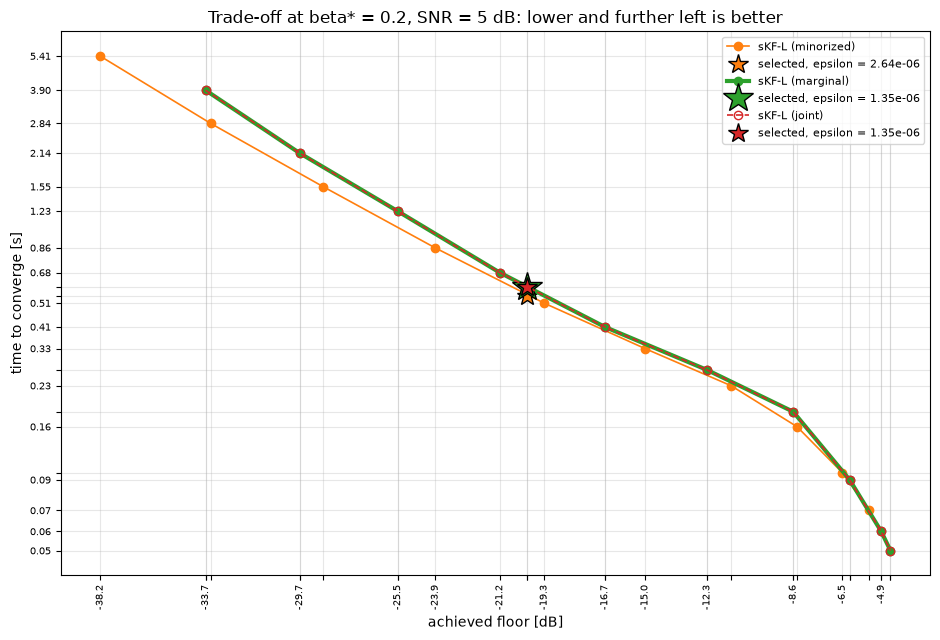

joint against minorized: common floor range -33.7 to -5.4 dB
   median separation between the curves: 9.6% of the minorized time
   no crossing: the joint filter needs more time at every floor in that range (by 7 to 7657 steps)


In [18]:
FIGURE2_TITLE = (f"Trade-off at beta* = {BETA}, SNR = {SNR_DB:.0f} dB: "
                 f"lower and further left is better")

fig, ax = plt.subplots(figsize=(9.5, 6.5))
grid_floors = {}                                   # the settled grid points of each filter
grid_times = {}
star_floors, star_times = [], []                   # the selected runs, off the grid

for name, result, colour in RESULTS_ROBUST:        # joint is last, so it is drawn on top
    # As in Figure 1: the marginal filter thick, the joint one dashed and thin over it.
    style = "o--" if name == "sKF-L (joint)" else "o-"
    face = "none" if name == "sKF-L (joint)" else colour
    width = 3.0 if name == "sKF-L (marginal)" else 1.2
    star_size = 22 if name == "sKF-L (marginal)" else 15
    keep = result["settled"]                       # unsettled points are out (section 4)
    grid_floors[name] = result["floors"][keep]
    grid_times[name] = result["steps"][keep]/FS
    ax.plot(grid_floors[name], grid_times[name], style, color=colour, mfc=face,
            linewidth=width, label=name)
    star_floors.append(float(result["floor"]))
    star_times.append(int(result["reached"])/FS)
    ax.plot(star_floors[-1], star_times[-1], "*", color=colour, markersize=star_size,
            markeredgecolor="k",
            label=f"selected, {SWEPT_NAME} = {float(result['value']):.2e}")

# Logarithmic in time, which spans decades, but with the times written out.
# One tick per plotted point and per star, so every coordinate is read off the axis.
ax.set_yscale("log")
ax.minorticks_off()
all_floors = np.concatenate(list(grid_floors.values()) + [np.array(star_floors)])
all_times = np.concatenate(list(grid_times.values()) + [np.array(star_times)])
ticks, labels = readable_ticks(all_floors, 0.045*np.ptp(all_floors), 1)
ax.set_xticks(ticks)
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ticks, labels = readable_ticks(all_times, 0.035*np.ptp(np.log10(all_times)), 2, log=True)
ax.set_yticks(ticks)
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("achieved floor [dB]")
ax.set_ylabel("time to converge [s]")
ax.set_title(FIGURE2_TITLE)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Do the curves cross? Time of both at the same floor, over the floor range both cover.
floors_min, times_min = grid_floors["sKF-L (minorized)"], grid_times["sKF-L (minorized)"]
floors_joint, times_joint = grid_floors["sKF-L (joint)"], grid_times["sKF-L (joint)"]
common = np.linspace(max(floors_min.min(), floors_joint.min()),
                     min(floors_min.max(), floors_joint.max()), 200)
reference = np.interp(common, np.sort(floors_min), times_min[np.argsort(floors_min)])
gap = np.interp(common, np.sort(floors_joint), times_joint[np.argsort(floors_joint)]) - reference
crossings = common[1:][np.diff(np.sign(gap)) != 0]
separation = 100*np.median(np.abs(gap)/reference)  # how far apart the curves really are
print(f"joint against minorized: common floor range {common[0]:.1f} to {common[-1]:.1f} dB")
print(f"   median separation between the curves: {separation:.1f}% of the minorized time")
if crossings.size:
    print("   the curves cross near floor [dB]: " + ", ".join(f"{f:.1f}" for f in crossings))
    print("   read that against the separation above: many crossings at a separation of a")
    print("   few percent mean the two curves coincide, not that they trade places")
else:
    slower = "joint" if gap.min() > 0 else "minorized"
    print(f"   no crossing: the {slower} filter needs more time at every floor in that range "
          f"(by {abs(gap).min()*FS:.0f} to {abs(gap).max()*FS:.0f} steps)")

## 6. SNR sweep

**Figure 3.** The minorized and the joint filter at five SNRs, under the two $b_\eta$ conventions, each at the $\varepsilon$ its own search picked to land on the target: every point is a race at equal floor. The marginal filter is left out, being the same filter as the joint one and the slowest of the three. The search is cheap, $R = 3$ over $N = 48000$ steps, and the curves are at $R = 10$.

In [19]:
# 25 and 30 dB are left out on purpose: at those SNRs the selected floors no longer land on the
# target (-40 and -48 dB), so the ratio stops being a race at equal floor and means nothing.
SWEEP_SNR = [0.0, 5.0, 10.0, 15.0, 20.0]     # the 5 dB of section 2 is among them
R_SEARCH = 3                # realisations while scanning the grid at each SNR
R_PLOT = 10                 # realisations for the curves tabulated below
N_SWEEP = 48000             # 6 s at 8 kHz: enough, both filters converge in a few thousand steps
SNR_CACHE = CACHE_PREFIX + "snr_sweep.npz"

# Changing the SNR moves the floors a filter can reach, so the grid of section 4 stops covering
# the target at the ends of the sweep. This one is wider: eight decades, same two points per decade.
EPS_GRID_SNR = np.logspace(-11, -3, 17)

# At beta* = 0.2 and only R_SEARCH = 3 realisations the average misalignment wanders more than
# 0.5 dB from quarter to quarter without being unconverged, as in notebook 04, so the drift rule
# is wider here than the DRIFT_DB of section 4.
DRIFT_DB_SWEEP = 1.2

# One column per filter and b_eta convention. Figure 3 divides column 1 by column 0 for the
# b_eta = E|eta| the notebook uses, and column 3 by column 2 for the sqrt(v_eta/2) of 03-06.
SNR_COLUMNS = [("sKF-L (minorized)", sKF_L_minorized, "E|eta|"),
               ("sKF-L (joint)", sKF_L_joint, "E|eta|"),
               ("sKF-L (minorized)", sKF_L_minorized, "sqrt(v/2)"),
               ("sKF-L (joint)", sKF_L_joint, "sqrt(v/2)")]


def search_at_snr(filter_function, grid, fixed_parameters, signals_search, signals_plot):
    """Scan the grid cheaply at the current SNR, pick the value that lands on the target, run it."""
    floors = np.zeros(len(grid))
    settled = np.zeros(len(grid), dtype=bool)
    for i in range(len(grid)):
        parameters = fixed_parameters.copy()
        parameters[SWEPT_NAME] = grid[i]
        misalignment = run_filter(filter_function, parameters, N_SWEEP, signals_search)
        floors[i] = steady_state(misalignment)[0]
        settled[i] = is_settled(misalignment, DRIFT_DB_SWEEP)

    if not settled.any():
        return {"value": np.nan, "floor": np.nan, "steps": -1, "best": np.nan}
    settled_values, settled_floors = grid[settled], floors[settled]
    if TARGET_DB < settled_floors.min() or TARGET_DB > settled_floors.max():
        # The target is outside the floors this grid reaches at this SNR. The deepest
        # settled floor says whether the grid is short or the filter simply cannot go there.
        return {"value": np.nan, "floor": np.nan, "steps": -1, "best": settled_floors.min()}

    order = np.argsort(settled_floors)
    value = 10**np.interp(TARGET_DB, settled_floors[order], np.log10(settled_values)[order])
    parameters = fixed_parameters.copy()
    parameters[SWEPT_NAME] = value
    misalignment = run_filter(filter_function, parameters, N_SWEEP, signals_plot)
    floor, reached = steady_state(misalignment)
    return {"value": value, "floor": floor, "steps": reached, "best": settled_floors.min()}


# One row per SNR, one column per entry of SNR_COLUMNS, in that order.
if os.path.exists(SNR_CACHE):
    with np.load(SNR_CACHE) as stored:
        snr_values, snr_floors, snr_steps = stored["values"], stored["floors"], stored["steps"]
        snr_best = stored["best"]
    print(f"SNR sweep loaded from {SNR_CACHE}")
else:
    print(f"computing the SNR sweep at {len(SWEEP_SNR)} SNRs, R = {R_SEARCH} while scanning")
    start = time.time()
    snr_values = np.zeros((len(SWEEP_SNR), len(SNR_COLUMNS)))
    snr_floors = np.zeros((len(SWEEP_SNR), len(SNR_COLUMNS)))
    snr_steps = np.zeros((len(SWEEP_SNR), len(SNR_COLUMNS)), dtype=int)
    snr_best = np.zeros((len(SWEEP_SNR), len(SNR_COLUMNS)))

    for row in range(len(SWEEP_SNR)):
        # generate_signals reads scale_gg off the globals, and the filters read b_eta, so this
        # loop reassigns var_eta, b_eta and scale_gg and puts the three back afterwards.
        var_eta = P_signal/10**(SWEEP_SNR[row]/10)
        scale_gg = np.sqrt(var_eta/np.exp(gammaln(3/BETA) - gammaln(1/BETA)))
        b_eta = laplace_scale(var_eta)
        b_by_rule = {"E|eta|": b_eta, "sqrt(v/2)": np.sqrt(var_eta/2)}

        signals_search = []
        for seed in range(R_SEARCH):
            x, d, eta = generate_signals(seed)
            signals_search.append((x, d))
        signals_plot = []
        for seed in range(R_PLOT):
            x, d, eta = generate_signals(seed)
            signals_plot.append((x, d))

        for column in range(len(SNR_COLUMNS)):
            name, filter_function, rule = SNR_COLUMNS[column]
            parameters_snr = {"b_eta": b_by_rule[rule], "var_theta_0": VAR_THETA_0}
            found = search_at_snr(filter_function, EPS_GRID_SNR, parameters_snr,
                                  signals_search, signals_plot)
            snr_values[row, column] = found["value"]
            snr_floors[row, column] = found["floor"]
            snr_steps[row, column] = found["steps"]
            snr_best[row, column] = found["best"]
        print(f"   SNR {SWEEP_SNR[row]:.0f} dB done   [{time.time() - start:.0f} s]")

    var_eta = P_signal/10**(SNR_DB/10)     # back to the scenario of section 2
    b_eta = laplace_scale(var_eta)
    scale_gg = np.sqrt(var_eta/np.exp(gammaln(3/BETA) - gammaln(1/BETA)))
    np.savez(SNR_CACHE, values=snr_values, floors=snr_floors, steps=snr_steps, best=snr_best)
    print(f"SNR sweep done in {(time.time() - start)/60:.1f} min, saved to {SNR_CACHE}")
    print(f"var_eta back to {var_eta:.4e}, the value section 2 printed")

SNR sweep loaded from ../cache/07_joint_mad_snr_sweep.npz


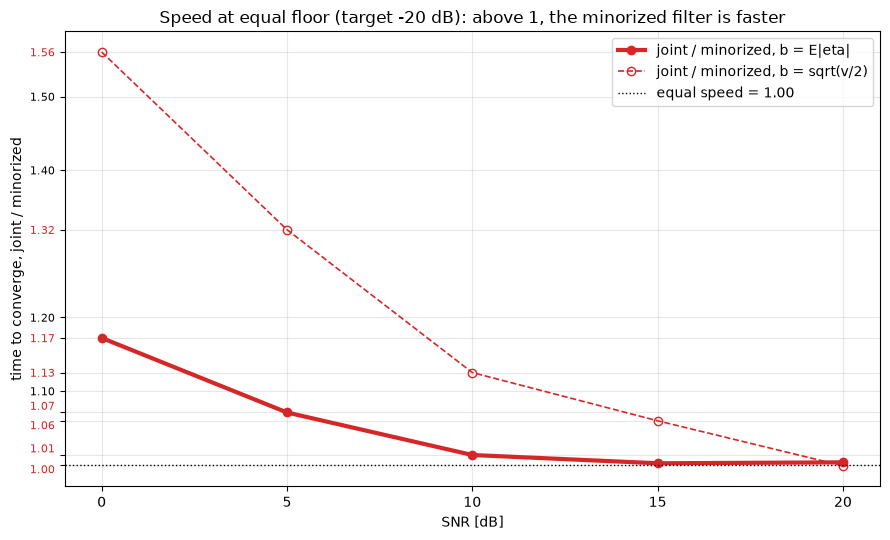

  SNR  filter                    b_eta    epsilon  floor [dB]    steps  time [s]
    0  sKF-L (minorized)        E|eta|   2.55e-06      -19.95     6313      0.79
    0  sKF-L (joint)            E|eta|   1.24e-06      -19.89     7400      0.93
    0  sKF-L (minorized)     sqrt(v/2)   7.18e-06      -19.95     6206      0.78
    0  sKF-L (joint)         sqrt(v/2)   2.74e-06      -19.87     9684      1.21
    5  sKF-L (minorized)        E|eta|   2.72e-06      -19.95     4312      0.54
    5  sKF-L (joint)            E|eta|   1.41e-06      -19.96     4618      0.58
    5  sKF-L (minorized)     sqrt(v/2)   7.70e-06      -19.95     4311      0.54
    5  sKF-L (joint)         sqrt(v/2)   3.48e-06      -19.99     5687      0.71
   10  sKF-L (minorized)        E|eta|   3.20e-06      -19.98     3405      0.43
   10  sKF-L (joint)            E|eta|   1.60e-06      -19.98     3450      0.43
   10  sKF-L (minorized)     sqrt(v/2)   9.05e-06      -19.96     3403      0.43
   10  sKF-L (joint)        

In [20]:
# Ratio of times at equal floor, one curve per b_eta convention. Columns 0 and 1 are the
# minorized and the joint filter at b = E|eta|, columns 2 and 3 the same pair at b = sqrt(v/2).
fig, ax = plt.subplots(figsize=(9, 5.5))
levels, colours_y = [1.0], ["k"]
missing = []
for rule, minorized_column, joint_column, style in [("E|eta|", 0, 1, "o-"),
                                                    ("sqrt(v/2)", 2, 3, "o--")]:
    # An SNR where either filter missed the target has no ratio to plot: it is left out
    # of the curve and listed under the figure.
    snr_kept, ratio = [], []
    for row in range(len(SWEEP_SNR)):
        steps_minorized = snr_steps[row, minorized_column]
        steps_joint = snr_steps[row, joint_column]
        if steps_minorized > 0 and steps_joint > 0:
            snr_kept.append(SWEEP_SNR[row])
            ratio.append(steps_joint/steps_minorized)
        else:
            missing.append(f"b = {rule} at {SWEEP_SNR[row]:.0f} dB")
    face = "none" if rule == "sqrt(v/2)" else "C3"
    width = 1.2 if rule == "sqrt(v/2)" else 3.0    # the thin dashed curve goes over the thick one
    ax.plot(snr_kept, ratio, style, color="C3", mfc=face, linewidth=width,
            label=f"joint / minorized, b = {rule}")
    for value in ratio:
        add_value(levels, colours_y, value, "C3", 2)

ax.axhline(1.0, color="k", linestyle=":", linewidth=1.0, label="equal speed = 1.00")
ax.set_xticks(SWEEP_SNR)                           # exactly the swept values
ax.set_xlabel("SNR [dB]")
ax.set_ylabel("time to converge, joint / minorized")
ax.set_title(f"Speed at equal floor (target {TARGET_DB:.0f} dB): above 1, the minorized filter is faster")
ax.legend()
ax.grid(alpha=0.3)
add_ticks(ax, "y", levels, colours_y, 2, 0.02)
plt.tight_layout()
plt.show()

print(f"{'SNR':>5}  {'filter':<20}{'b_eta':>11}{'epsilon':>11}{'floor [dB]':>12}"
      f"{'steps':>9}{'time [s]':>10}")
for row in range(len(SWEEP_SNR)):
    for column in range(len(SNR_COLUMNS)):
        name, filter_function, rule = SNR_COLUMNS[column]
        value, floor = snr_values[row, column], snr_floors[row, column]
        steps = snr_steps[row, column]
        value_text = "-" if np.isnan(value) else f"{value:.2e}"
        steps_text = "-" if steps < 0 else str(steps)
        time_text = "-" if steps < 0 else f"{steps/FS:.2f}"
        note = "" if steps > 0 else f"  deepest settled floor {snr_best[row, column]:+.2f} dB"
        print(f"{SWEEP_SNR[row]:>5.0f}  {name:<20}{rule:>11}{value_text:>11}{floor:>12.2f}"
              f"{steps_text:>9}{time_text:>10}{note}")

print()
if missing:
    print("   no ratio at: " + ", ".join(missing))
    print("   at those SNRs the target sits outside the floors the grid reaches, so the")
    print("   interpolation has nothing to land on and the point is left out of the figure.")
    print("   Compare the target with the deepest settled floor printed on each of those rows:")
    print("   if that floor is above the target, no value of epsilon gets there at all.")
print("   the search here is cheap (R = 3 over N = 48000) and the curves are at R = 10, so")
print("   these floors and steps are noisier than the ones of Figure 1; the ratio is what matters")
print()
print("   caveat: the target is -20 dB at every SNR. As epsilon grows both filters tend to the same")
print("   NLMS floor, about -SNR dB, so a fixed target sits closer to where they coincide the higher")
print("   the SNR, and that alone pushes the ratio towards 1. With the moving target -(SNR + 15) dB and")
print("   b = E|eta|, Ramiro's 04_escenario_realista_large_k_mad (DECISIONS.md, 2026-09-21) gives")
print("   joint/minorized 1.11, 1.09, 1.06, 1.01, 0.99, 0.96, 0.93 at 0, 5, 10, 15, 20, 25, 30 dB.")
print(f"\nwhole notebook: {(time.time() - NOTEBOOK_START)/60:.1f} min")